In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from skimage import io
import numpy as np
import seaborn as sns

In [11]:
df = pd.read_csv("flood_land_data.csv", index_col=0)

In [12]:
df.head(5)

,x_coord,y_coord,image_source_x,water_percentage,date,year,image_source_y,inland_aquaculture,shrimp_rice_farming,single_rice_cropping,triple_rice_cropping,double_rice_cropping_dry,double_rice_cropping_rain,others,date_time
47440,10,5,Flood_2000_153.tif,0.20,153,2000,Landuse_2000.tif,0.09,0.02,0.01,0.02,0.00,0.04,0.81,2000-06-01
6539,2,12,Flood_2000_153.tif,0.58,153,2000,Landuse_2000.tif,0.60,0.05,0.00,0.01,0.00,0.00,0.34,2000-06-01
6537,2,7,Flood_2000_153.tif,0.30,153,2000,Landuse_2000.tif,0.05,0.05,0.04,0.00,0.00,0.04,0.82,2000-06-01
9994,3,1,Flood_2000_153.tif,0.09,153,2000,Landuse_2000.tif,0.00,0.02,0.05,0.05,0.63,0.00,0.26,2000-06-01
43627,9,5,Flood_2000_153.tif,0.05,153,2000,Landuse_2000.tif,0.01,0.01,0.00,0.41,0.00,0.04,0.54,2000-06-01


In [13]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 56133 entries, 47440 to 6621
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   x_coord                    56133 non-null  int64  
 1   y_coord                    56133 non-null  int64  
 2   image_source_x             55935 non-null  object 
 3   water_percentage           56133 non-null  float64
 4   date                       56133 non-null  int64  
 5   year                       56133 non-null  int64  
 6   image_source_y             56133 non-null  object 
 7   inland_aquaculture         56133 non-null  float64
 8   shrimp_rice_farming        56133 non-null  float64
 9   single_rice_cropping       56133 non-null  float64
 10  triple_rice_cropping       56133 non-null  float64
 11  double_rice_cropping_dry   56133 non-null  float64
 12  double_rice_cropping_rain  56133 non-null  float64
 13  others                     56133 non-null  float

In [14]:
# Create a datetime column
df["date_time"] = pd.to_datetime(df["year"].astype(str) + df["date"].astype(str), format="%Y%j")
df = df.sort_values("date_time")

## Data structure inspection

#### 1. Overview of the dataset

- Observation period: from 2000 to 2020
- Total observations: 56331
- Number of grid cells: 99 (number of x coords: 13, y coords:14)
- Missing value: 198. Missing data is imputed during data extraction step
- Target variable: water percentage
- Input variables: date, time, land-use

In [15]:
# number of grid cells (x, y coords)
num_unique_grids = len(df[["y_coord"]].drop_duplicates())
print(num_unique_grids)

14


In [16]:
len(df["date"].drop_duplicates())

27

#### 2. Water percentage

In [17]:
color_pallete = ["#9edae1","#345f97","#c8e2bb", "#e7efba"]

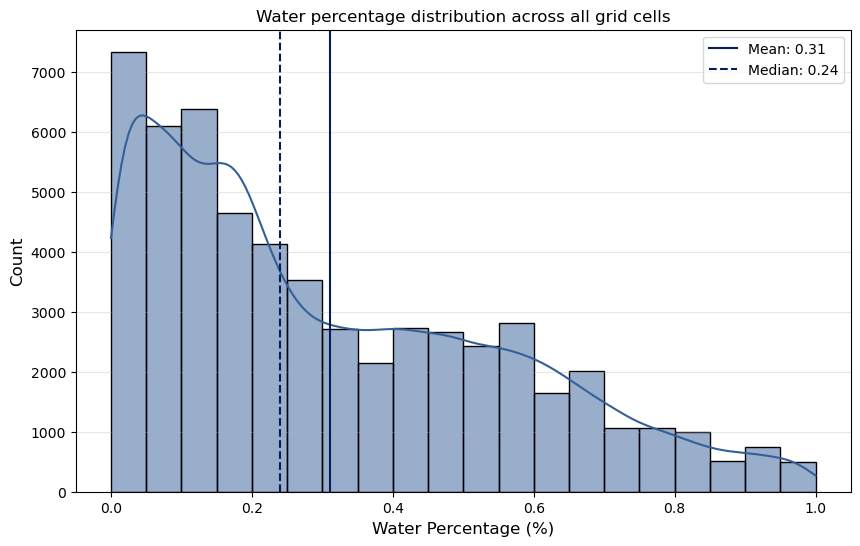

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(df["water_percentage"], kde=True, color=color_pallete[1], bins=20)

mean_water = df["water_percentage"].mean()
median_water = df["water_percentage"].median()

plt.axvline(mean_water, color="#081d58", linestyle='-', label=f'Mean: {mean_water:.2f}')
plt.axvline(median_water, color="#081d58", linestyle='--', label=f'Median: {median_water:.2f}')

plt.title("Water percentage distribution across all grid cells", fontsize=12)
plt.xlabel("Water Percentage (%)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("water_distribution_all.png", dpi=300, bbox_inches="tight")
plt.show()

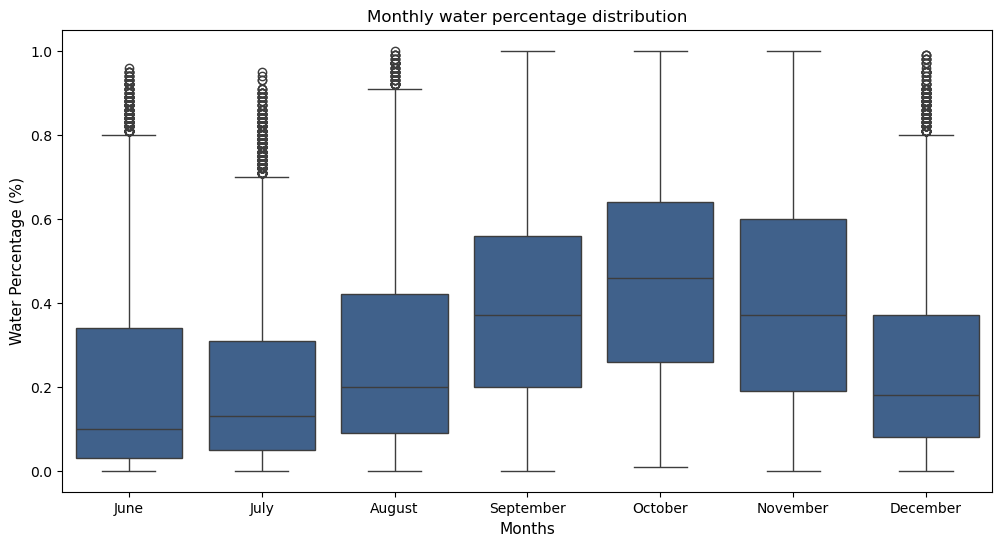

In [35]:
# Water percentage distribution per month
df["month"] = df["date_time"].dt.month_name()

plt.figure(figsize=(12,6))
sns.boxplot(x="month", y="water_percentage", data=df, color=color_pallete[1])
plt.title("Monthly water percentage distribution")
plt.xlabel("Months", fontsize=11)
plt.ylabel("Water Percentage (%)", fontsize=11)
plt.savefig("water_distribution_per_month.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3. Water percentage and time-series

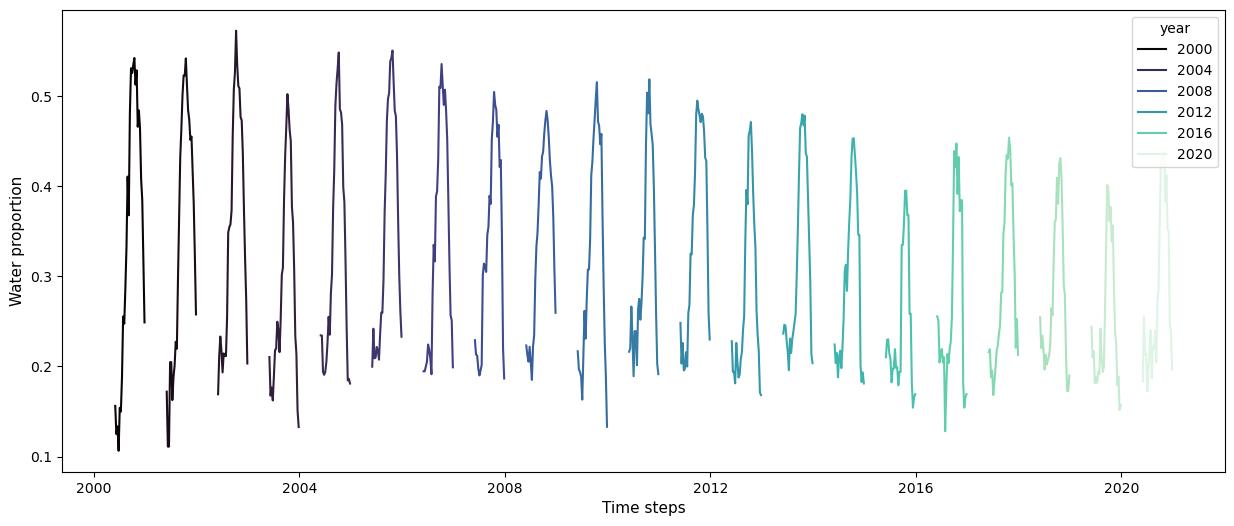

In [33]:
# Visualize timestep using mean water_percentage
plt.figure(figsize=(15,6))
sns.lineplot(data=df, x="date_time", y="water_percentage", hue="year", palette="mako", errorbar=None)
plt.xlabel("Time steps", fontsize=11)
plt.ylabel("Water proportion", fontsize=11)
#plt.savefig("water_timesteps.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4. Water percentage across grids and time

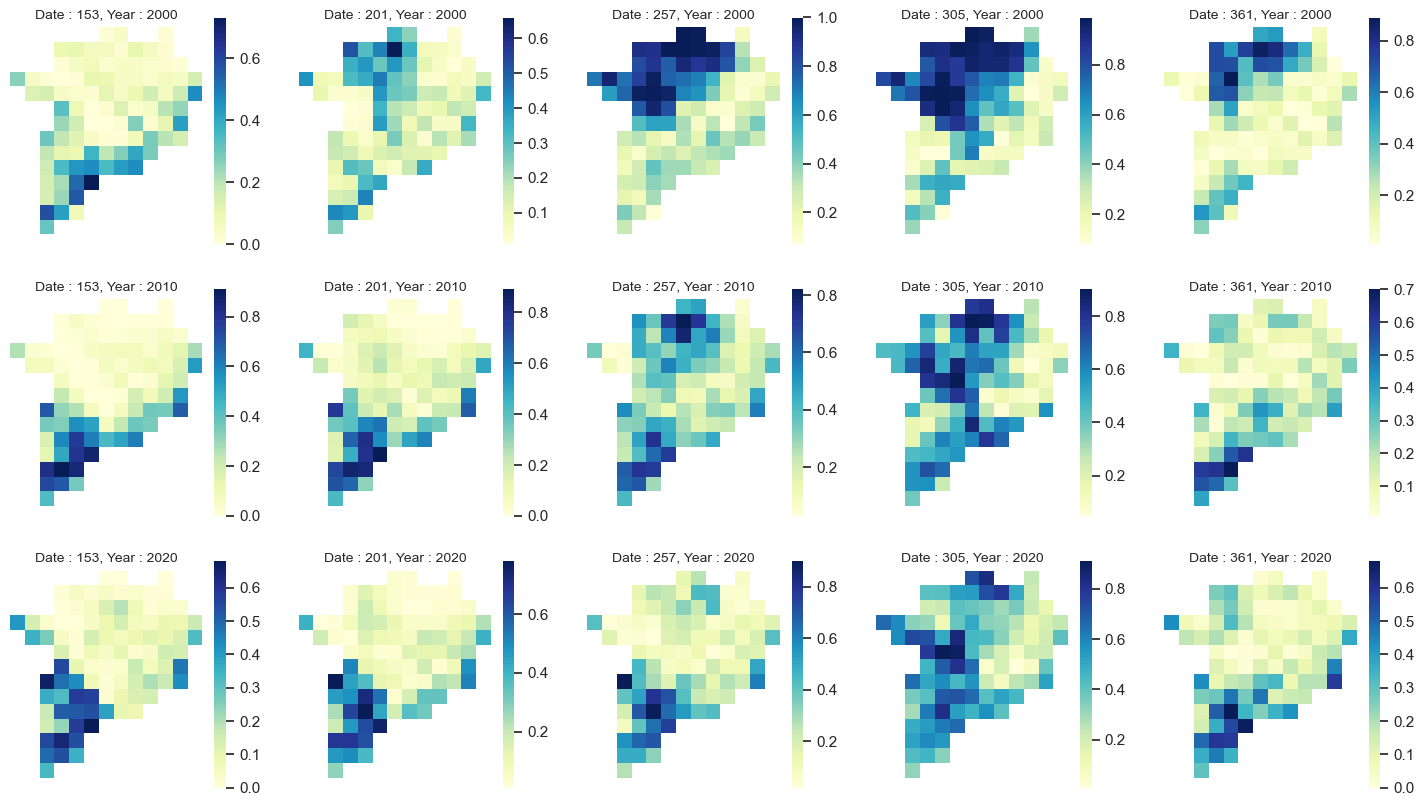

In [284]:
# Subset data
years = [2000, 2010, 2020]
days = [153, 201, 257, 305, 361]

plt.figure(figsize=(18,10))
i=0

while i != 15:
    for year in years:
        for day in days:
            selected_data = df[(df["date"] == day) & (df["year"] == year)]
            heatmap_data = selected_data.pivot_table(index="y_coord", columns="x_coord", values="water_percentage")
            plt.subplot(3,5,i+1), plt.axis("off")
            sns.heatmap(heatmap_data, cmap="YlGnBu", square=True)
            plt.title(f"Date : {day}, Year : {year}", fontsize=10)
            i += 1
plt.savefig("water_grids.png", dpi=300, bbox_inches="tight")
plt.show()

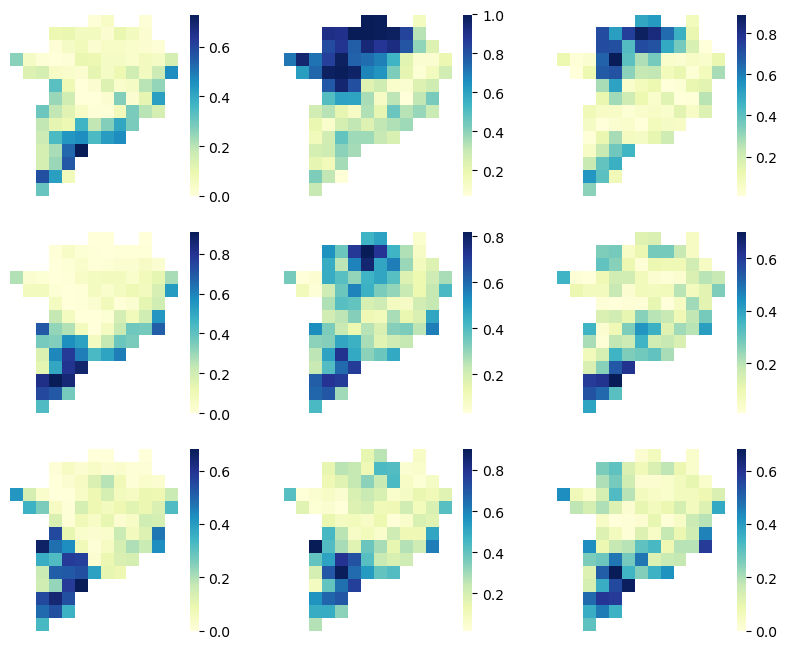

In [9]:
# Subset data
years = [2000, 2010, 2020]
days = [153, 257, 361]

plt.figure(figsize=(10,8))
i=0

while i != 9:
    for year in years:
        for day in days:
            selected_data = df[(df["date"] == day) & (df["year"] == year)]
            heatmap_data = selected_data.pivot_table(index="y_coord", columns="x_coord", values="water_percentage")
            plt.subplot(3,3,i+1), plt.axis("off")
            sns.heatmap(heatmap_data, cmap="YlGnBu", square=True)
            i += 1
plt.savefig("after_extraction.png", dpi=300, bbox_inches="tight")
plt.show()

In [250]:
df.head()

,x_coord,y_coord,image_source_x,water_percentage,date,year,image_source_y,inland_aquaculture,shrimp_rice_farming,single_rice_cropping,triple_rice_cropping,double_rice_cropping_dry,double_rice_cropping_rain,others,date_time,month
23935,5,7,Flood_2000_153.tif,0.04,153,2000,Landuse_2000.tif,0.00,0.00,0.00,0.32,0.06,0.03,0.58,2000-06-01,June
8574,3,4,Flood_2000_153.tif,0.04,153,2000,Landuse_2000.tif,0.00,0.00,0.01,0.02,0.84,0.00,0.13,2000-06-01,June
43234,9,5,Flood_2000_153.tif,0.05,153,2000,Landuse_2000.tif,0.01,0.01,0.00,0.41,0.00,0.04,0.54,2000-06-01,June
23777,5,4,Flood_2000_153.tif,0.02,153,2000,Landuse_2000.tif,0.00,0.00,0.00,0.17,0.54,0.03,0.25,2000-06-01,June
23831,5,6,Flood_2000_153.tif,0.00,153,2000,Landuse_2000.tif,0.00,0.00,0.00,0.09,0.60,0.01,0.30,2000-06-01,June


#### 5. Land-use variables

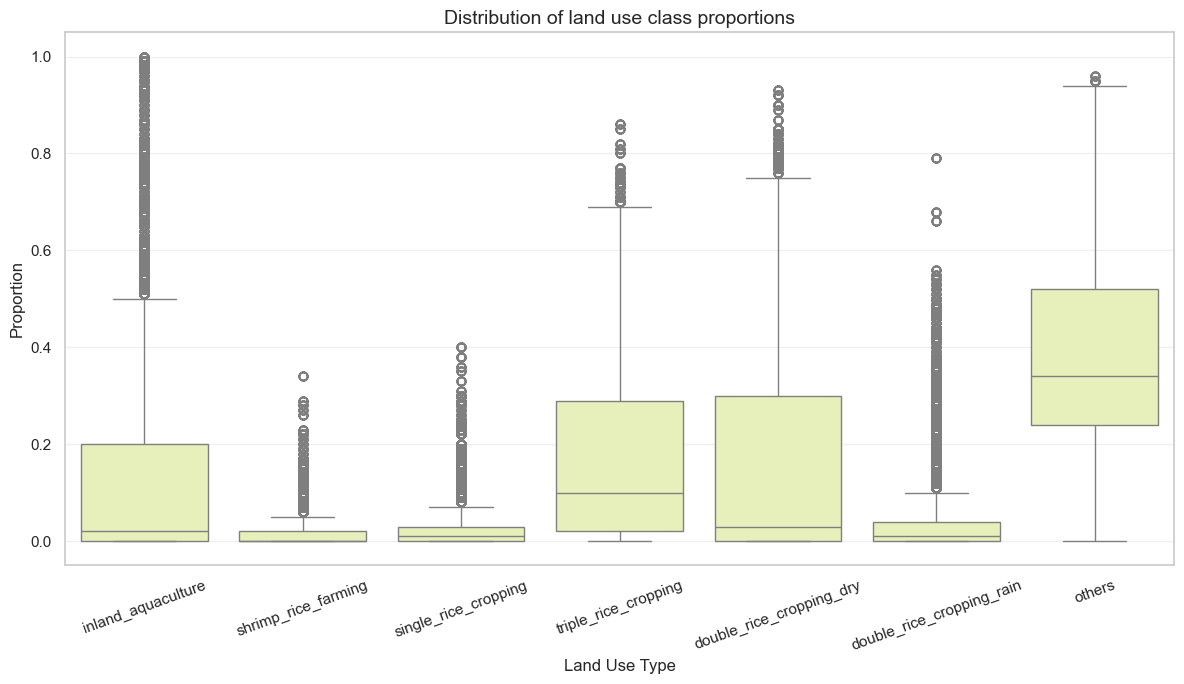

In [285]:
land_use_cols = ["inland_aquaculture", "shrimp_rice_farming", "single_rice_cropping",
                 "triple_rice_cropping", "double_rice_cropping_dry", 
                 "double_rice_cropping_rain", "others"]

df_land_use = df[land_use_cols].melt(var_name="land_use_category", 
                                     value_name="proportion")
plt.figure(figsize=(12, 7))
sns.boxplot(x="land_use_category", 
            y="proportion", 
            data=df_land_use, 
            color="#edf8b1")

plt.title("Distribution of land use class proportions", fontsize=14)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Land Use Type", fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("land_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

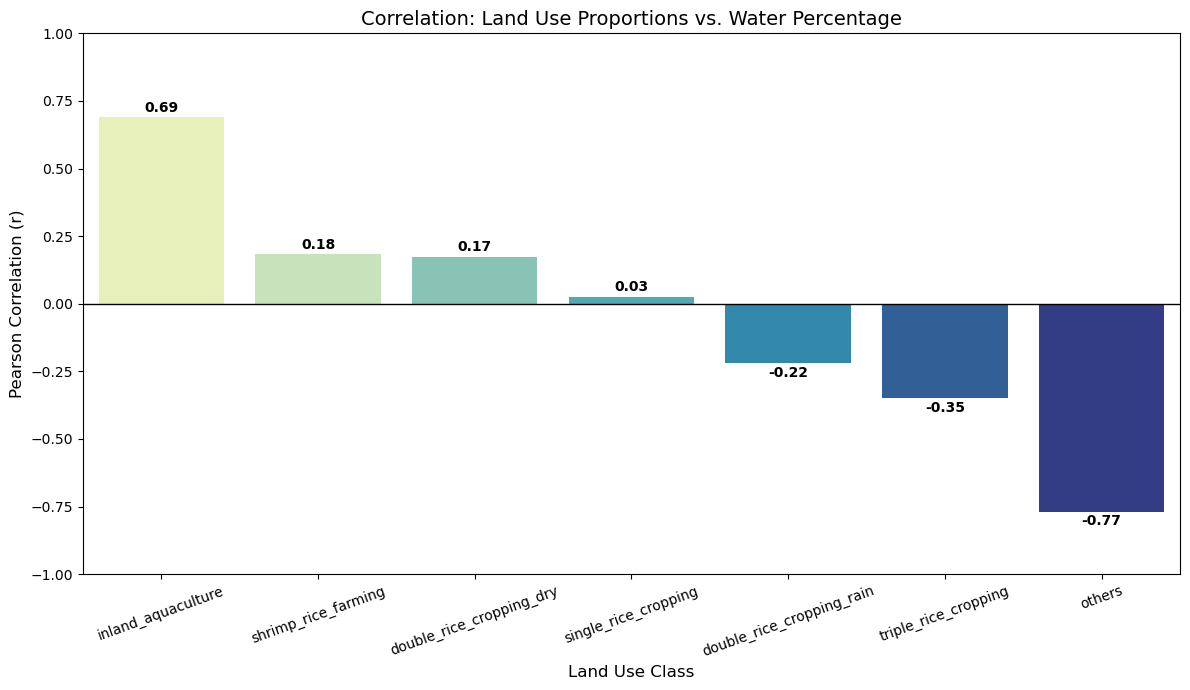

In [36]:
water_land_per_grid = df.groupby(["x_coord", "y_coord"]).agg({
    "water_percentage": "mean",
    "shrimp_rice_farming": "mean",
    "single_rice_cropping": "mean",
    "triple_rice_cropping": "mean",
    "double_rice_cropping_dry": "mean",
    "double_rice_cropping_rain": "mean",
    "inland_aquaculture": "mean",
    "others": "mean"
}).reset_index()

# Calculate correlation between average proportion of water and land categories
land_use_cols = ["shrimp_rice_farming", "single_rice_cropping", 
                 "triple_rice_cropping", "double_rice_cropping_dry",
                 "double_rice_cropping_rain", "inland_aquaculture", "others"]

correlations = water_land_per_grid[land_use_cols].corrwith(water_land_per_grid["water_percentage"])
corr_df = correlations.sort_values(ascending=False).reset_index()
corr_df.columns = ["Land_Use_Class", "Correlation"]

# 3. Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x="Land_Use_Class", y="Correlation", data=corr_df, hue="Land_Use_Class", palette="YlGnBu")
plt.axhline(0, color="black", linewidth=1)
plt.title("Correlation: Land Use Proportions vs. Water Percentage", fontsize=14)
plt.ylabel("Pearson Correlation (r)", fontsize=12)
plt.xlabel("Land Use Class", fontsize=12)
plt.xticks(rotation=20)
plt.ylim(-1, 1)

# Annotate bars with the exact value
for i, val in enumerate(corr_df["Correlation"]):
    plt.text(
        i, 
        val + (0.02 if val > 0 else -0.05), 
        f"{val:.2f}", 
        ha="center", 
        fontsize=10, 
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("land_water_corr.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
import importlib.metadata as md
import sys

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "scikit-image",
    "statsmodels",
    "rasterio",
    "keras",
    "tensorflow"
]

lines = []

python_version = f"Python: {sys.version.split()[0]}"
print(python_version)
lines.append(python_version)

for package in packages:
    try:
        line = f"{package}: {md.version(package)}"
    except md.PackageNotFoundError:
        line = f"{package}: not installed"
    
    print(line)
    lines.append(line)

with open("requirements.txt", "w") as file:
    file.write("\n".join(lines))

Python: 3.13.5
numpy: 2.1.3
pandas: 2.3.2
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
scikit-image: 0.25.0
statsmodels: 0.14.6
rasterio: 1.5.0
keras: 3.13.2
tensorflow: 2.20.0
